In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 2000

categories = ["Electronics", "Fashion", "Home & Kitchen", "Beauty", "Sports", "Books"]

df = pd.DataFrame({
    "User_ID": [f"U{str(i).zfill(4)}" for i in np.random.randint(1, 500, n)],
    "Product_ID": [f"P{str(i).zfill(4)}" for i in np.random.randint(1, 300, n)],
    "Product_Category": np.random.choice(categories, n),
    "Price": np.random.randint(100, 20000, n),
    "Number_of_Views": np.random.randint(1, 50, n),
    "Time_Spent": np.round(np.random.exponential(scale=5, size=n), 2),
    "Previous_Purchases": np.random.randint(0, 30, n),
    "Cart_Status": np.random.choice([0, 1], n, p=[0.4, 0.6]),
})

# Rating influenced by Time_Spent, Number_of_Views, Previous_Purchases
base_rating = (
    2.5
    + 0.12 * df["Time_Spent"].clip(upper=10)
    + 0.02 * df["Number_of_Views"]
    + 0.03 * df["Previous_Purchases"]
    + np.random.normal(0, 0.6, n)
)
df["Rating"] = base_rating.clip(1, 5).round(1)

# Purchase_Status influenced by Cart_Status, Time_Spent, Rating
purchase_score = (
    0.5 * df["Cart_Status"]
    + 0.04 * df["Number_of_Views"]
    + 0.05 * df["Time_Spent"].clip(upper=10)
    + 0.15 * (df["Rating"] - 2.5)
    + np.random.normal(0, 0.3, n)
)
df["Purchase_Status"] = (purchase_score > 0.9).astype(int)

# Introduce missing values + duplicates for realistic preprocessing
df.loc[np.random.choice(df.index, 35, replace=False), "Price"] = np.nan
df.loc[np.random.choice(df.index, 25, replace=False), "Rating"] = np.nan
df = pd.concat([df, df.sample(10, random_state=1)], ignore_index=True)  # inject duplicates

df.to_csv("ecommerce_multi_algo_data.csv", index=False)
print("Dataset created:", df.shape)
df.head()

Dataset created: (2010, 10)


,User_ID,Product_ID,Product_Category,Price,Number_of_Views,Time_Spent,Previous_Purchases,Cart_Status,Rating,Purchase_Status
0,U0103,P0131,Fashion,7797.0,44,11.64,5,1,5.0,1
1,U0436,P0293,Books,14729.0,39,0.38,0,0,3.2,1
2,U0349,P0171,Sports,8486.0,47,11.23,29,0,5.0,1
3,U0271,P0183,Books,17146.0,39,1.29,13,1,3.0,1
4,U0107,P0039,Home & Kitchen,8144.0,29,6.74,2,0,5.0,1


In [ ]:
df = pd.read_csv("ecommerce_multi_algo_data.csv")

print("Shape:", df.shape)
print("\nColumn Names:", list(df.columns))
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

Shape: (2010, 10)

Column Names: ['User_ID', 'Product_ID', 'Product_Category', 'Price', 'Number_of_Views', 'Time_Spent', 'Previous_Purchases', 'Cart_Status', 'Rating', 'Purchase_Status']

Data Types:
 User_ID                object
Product_ID             object
Product_Category       object
Price                 float64
Number_of_Views         int64
Time_Spent            float64
Previous_Purchases      int64
Cart_Status             int64
Rating                float64
Purchase_Status         int64
dtype: object

Missing Values:
 User_ID                0
Product_ID             0
Product_Category       0
Price                 35
Number_of_Views        0
Time_Spent             0
Previous_Purchases     0
Cart_Status            0
Rating                25
Purchase_Status        0
dtype: int64

Duplicate Rows: 10


In [3]:
# Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)

# Handle missing values
df["Price"] = df["Price"].fillna(df["Price"].median())
df["Rating"] = df["Rating"].fillna(df["Rating"].median())

print("Shape after cleaning:", df.shape)
print("Missing values after cleaning:\n", df.isnull().sum())

Shape after cleaning: (2000, 10)
Missing values after cleaning:
 User_ID               0
Product_ID            0
Product_Category      0
Price                 0
Number_of_Views       0
Time_Spent            0
Previous_Purchases    0
Cart_Status           0
Rating                0
Purchase_Status       0
dtype: int64


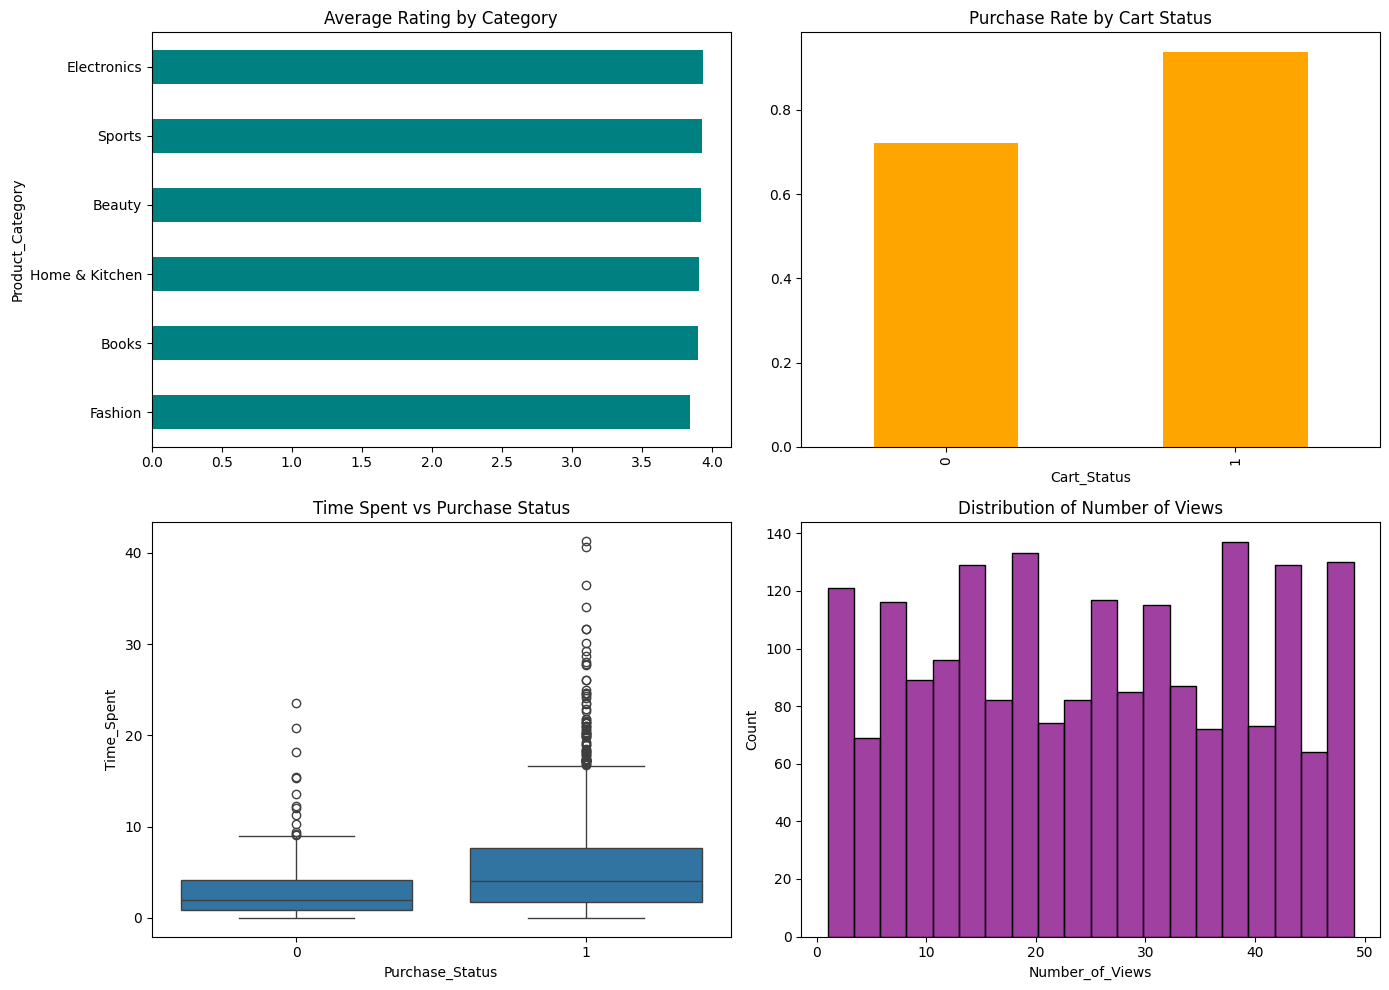

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df.groupby("Product_Category")["Rating"].mean().sort_values().plot(kind="barh", ax=axes[0,0], color="teal")
axes[0,0].set_title("Average Rating by Category")

df.groupby("Cart_Status")["Purchase_Status"].mean().plot(kind="bar", ax=axes[0,1], color="orange")
axes[0,1].set_title("Purchase Rate by Cart Status")

sns.boxplot(x="Purchase_Status", y="Time_Spent", data=df, ax=axes[1,0])
axes[1,0].set_title("Time Spent vs Purchase Status")

sns.histplot(df["Number_of_Views"], bins=20, ax=axes[1,1], color="purple")
axes[1,1].set_title("Distribution of Number of Views")

plt.tight_layout()
plt.savefig("eda_charts_task7.png")
plt.show()

In [5]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
le_category = LabelEncoder()
df_encoded["Category_enc"] = le_category.fit_transform(df_encoded["Product_Category"])
df_encoded.head()

,User_ID,Product_ID,Product_Category,Price,Number_of_Views,Time_Spent,Previous_Purchases,Cart_Status,Rating,Purchase_Status,Category_enc
0,U0103,P0131,Fashion,7797.0,44,11.64,5,1,5.0,1,3
1,U0436,P0293,Books,14729.0,39,0.38,0,0,3.2,1,1
2,U0349,P0171,Sports,8486.0,47,11.23,29,0,5.0,1,5
3,U0271,P0183,Books,17146.0,39,1.29,13,1,3.0,1,1
4,U0107,P0039,Home & Kitchen,8144.0,29,6.74,2,0,5.0,1,4


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

reg_features = ["Price", "Category_enc", "Number_of_Views", "Time_Spent", "Previous_Purchases", "Cart_Status"]

X_reg = df_encoded[reg_features]
y_reg = df_encoded["Rating"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)

ridge_base = Ridge(alpha=1.0)
ridge_base.fit(X_train_r_scaled, y_train_r)
y_pred_base_r = ridge_base.predict(X_test_r_scaled)

mae_base = mean_absolute_error(y_test_r, y_pred_base_r)
rmse_base = np.sqrt(mean_squared_error(y_test_r, y_pred_base_r))
r2_base = r2_score(y_test_r, y_pred_base_r)

print("BEFORE TUNING (alpha=1.0 default):")
print("MAE:", round(mae_base, 3), "| RMSE:", round(rmse_base, 3), "| R2:", round(r2_base, 3))

BEFORE TUNING (alpha=1.0 default):
MAE: 0.46 | RMSE: 0.569 | R2: 0.421


In [7]:
from sklearn.model_selection import GridSearchCV

ridge_params = {"alpha": [0.01, 0.1, 1, 10, 100]}
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring="r2")
ridge_grid.fit(X_train_r_scaled, y_train_r)

best_ridge = ridge_grid.best_estimator_
y_pred_tuned_r = best_ridge.predict(X_test_r_scaled)

mae_tuned = mean_absolute_error(y_test_r, y_pred_tuned_r)
rmse_tuned = np.sqrt(mean_squared_error(y_test_r, y_pred_tuned_r))
r2_tuned = r2_score(y_test_r, y_pred_tuned_r)

print("Best alpha:", ridge_grid.best_params_)
print("\nAFTER TUNING:")
print("MAE:", round(mae_tuned, 3), "| RMSE:", round(rmse_tuned, 3), "| R2:", round(r2_tuned, 3))

print("\n--- BEFORE vs AFTER ---")
print(f"MAE:  {round(mae_base,3)} -> {round(mae_tuned,3)}")
print(f"RMSE: {round(rmse_base,3)} -> {round(rmse_tuned,3)}")
print(f"R2:   {round(r2_base,3)} -> {round(r2_tuned,3)}")

Best alpha: {'alpha': 10}

AFTER TUNING:
MAE: 0.461 | RMSE: 0.569 | R2: 0.421

--- BEFORE vs AFTER ---
MAE:  0.46 -> 0.461
RMSE: 0.569 -> 0.569
R2:   0.421 -> 0.421


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

clf_features = ["Price", "Category_enc", "Number_of_Views", "Cart_Status", "Time_Spent", "Previous_Purchases", "Rating"]

X_clf = df_encoded[clf_features]
y_clf = df_encoded["Purchase_Status"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

log_base = LogisticRegression(max_iter=200, random_state=42)
log_base.fit(X_train_c_scaled, y_train_c)
y_pred_base_c = log_base.predict(X_test_c_scaled)

print("BEFORE TUNING (default params):")
print("Accuracy:", round(accuracy_score(y_test_c, y_pred_base_c), 3))
print("Precision:", round(precision_score(y_test_c, y_pred_base_c), 3))
print("Recall:", round(recall_score(y_test_c, y_pred_base_c), 3))
print("F1:", round(f1_score(y_test_c, y_pred_base_c), 3))
print("Confusion Matrix:\n", confusion_matrix(y_test_c, y_pred_base_c))

BEFORE TUNING (default params):
Accuracy: 0.932
Precision: 0.956
Recall: 0.965
F1: 0.961
Confusion Matrix:
 [[ 44  15]
 [ 12 329]]


In [9]:
log_params = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"],
    "max_iter": [100, 200, 500]
}

log_grid = GridSearchCV(LogisticRegression(random_state=42), log_params, cv=5, scoring="f1")
log_grid.fit(X_train_c_scaled, y_train_c)

best_log = log_grid.best_estimator_
y_pred_tuned_c = best_log.predict(X_test_c_scaled)

print("Best Params:", log_grid.best_params_)
print("\nAFTER TUNING:")
print("Accuracy:", round(accuracy_score(y_test_c, y_pred_tuned_c), 3))
print("Precision:", round(precision_score(y_test_c, y_pred_tuned_c), 3))
print("Recall:", round(recall_score(y_test_c, y_pred_tuned_c), 3))
print("F1:", round(f1_score(y_test_c, y_pred_tuned_c), 3))
print("Confusion Matrix:\n", confusion_matrix(y_test_c, y_pred_tuned_c))

Best Params: {'C': 1, 'max_iter': 100, 'solver': 'lbfgs'}

AFTER TUNING:
Accuracy: 0.932
Precision: 0.956
Recall: 0.965
F1: 0.961
Confusion Matrix:
 [[ 44  15]
 [ 12 329]]


In [10]:
customer_df = df_encoded.groupby("User_ID").agg(
    Number_of_Views=("Number_of_Views", "sum"),
    Previous_Purchases=("Previous_Purchases", "max"),
    Average_Rating=("Rating", "mean"),
    Average_Time_Spent=("Time_Spent", "mean"),
    Total_Spending=("Price", "sum"),
    Cart_Additions=("Cart_Status", "sum")
).reset_index()

print("Customer-level shape:", customer_df.shape)
customer_df.head()

Customer-level shape: (488, 7)


,User_ID,Number_of_Views,Previous_Purchases,Average_Rating,Average_Time_Spent,Total_Spending,Cart_Additions
0,U0001,273,20,3.950000,3.378750,75948.0,2
1,U0002,66,23,3.475000,1.627500,29420.0,3
2,U0003,2,20,2.500000,0.590000,7447.0,0
3,U0004,70,27,3.860000,5.498000,34419.0,5
4,U0005,161,28,3.742857,2.085714,58638.0,7


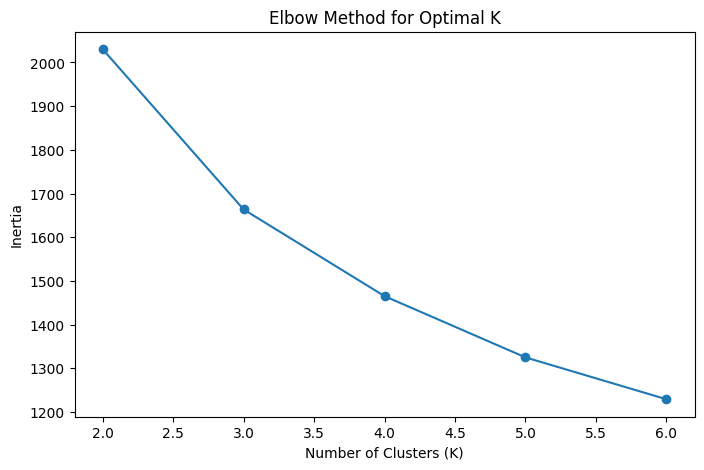

In [11]:
from sklearn.cluster import KMeans

cluster_features = ["Number_of_Views", "Previous_Purchases", "Average_Rating",
                     "Average_Time_Spent", "Total_Spending", "Cart_Additions"]

X_cluster = customer_df[cluster_features]
scaler_k = StandardScaler()
X_cluster_scaled = scaler_k.fit_transform(X_cluster)

inertias = []
K_range = range(2, 7)
for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(list(K_range), inertias, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.savefig("elbow_method_task7.png")
plt.show()

In [12]:
from sklearn.metrics import silhouette_score

optimal_k = 4  # adjust based on your elbow chart

kmeans = KMeans(n_clusters=optimal_k, init="k-means++", random_state=42, n_init=10)
customer_df["Cluster"] = kmeans.fit_predict(X_cluster_scaled)

sil_score = silhouette_score(X_cluster_scaled, customer_df["Cluster"])
print("Silhouette Score:", round(sil_score, 3))
print("Inertia:", round(kmeans.inertia_, 2))
print("\nCluster Sizes:\n", customer_df["Cluster"].value_counts())
print("\nCluster Profiles:\n", customer_df.groupby("Cluster")[cluster_features].mean().round(2))

Silhouette Score: 0.212
Inertia: 1465.2

Cluster Sizes:
 Cluster
2    179
0    161
1     77
3     71
Name: count, dtype: int64

Cluster Profiles:
          Number_of_Views  Previous_Purchases  Average_Rating  \
Cluster                                                        
0                 164.79               25.24            3.93   
1                  64.17               20.70            4.36   
2                  85.63               23.99            3.90   
3                  43.13               13.28            3.38   

         Average_Time_Spent  Total_Spending  Cart_Additions  
Cluster                                                      
0                      5.18        65645.19            4.17  
1                      9.11        26022.39            1.40  
2                      3.97        34104.06            1.97  
3                      3.20        18786.59            1.21  


In [13]:
comparison = pd.DataFrame({
    "ML Task": ["Regression", "Classification", "Clustering"],
    "Algorithm Used": ["Ridge Regression", "Logistic Regression", "K-Means"],
    "Target / Goal": ["Predict product rating", "Predict purchase likelihood", "Segment customers"],
    "Metrics Used": ["MAE, RMSE, R²", "Accuracy, Precision, Recall, F1", "Inertia, Silhouette Score"],
    "Best Result": [
        f"MAE={round(mae_tuned,3)}, RMSE={round(rmse_tuned,3)}, R2={round(r2_tuned,3)}",
        f"Accuracy={round(accuracy_score(y_test_c, y_pred_tuned_c),3)}, F1={round(f1_score(y_test_c, y_pred_tuned_c),3)}",
        f"Silhouette={round(sil_score,3)}, Inertia={round(kmeans.inertia_,2)}"
    ],
    "Business Use": ["Recommend highly rated products", "Target likely buyers", "Create customer groups"]
})

print(comparison.to_string(index=False))
comparison.to_csv("model_comparison_task7.csv", index=False)

       ML Task      Algorithm Used               Target / Goal                    Metrics Used                      Best Result                    Business Use
    Regression    Ridge Regression      Predict product rating                   MAE, RMSE, R²  MAE=0.461, RMSE=0.569, R2=0.421 Recommend highly rated products
Classification Logistic Regression Predict purchase likelihood Accuracy, Precision, Recall, F1         Accuracy=0.932, F1=0.961            Target likely buyers
    Clustering             K-Means           Segment customers       Inertia, Silhouette Score Silhouette=0.212, Inertia=1465.2          Create customer groups


In [14]:
report = f"""# Multi-Algorithm Recommendation System Comparison Report

## 1. Project Title
Multi-Algorithm Recommendation System Comparison for E-Commerce

## 2. Problem Statement
Build and compare regression, classification, and clustering models to support
product recommendations, purchase prediction, and customer segmentation for an
e-commerce business.

## 3. Dataset Description
Synthetic e-commerce dataset ({df.shape[0]} rows) with columns: User_ID, Product_ID,
Product_Category, Price, Number_of_Views, Time_Spent, Previous_Purchases, Cart_Status,
Rating, Purchase_Status.

## 4. Data Preprocessing
- Removed duplicate records
- Filled missing Price and Rating values with median
- Encoded Product_Category using LabelEncoder
- Scaled numeric features using StandardScaler
- 80/20 train-test split

## 5. Regression Model (Ridge Regression)
- Before tuning: MAE={round(mae_base,3)}, RMSE={round(rmse_base,3)}, R2={round(r2_base,3)}
- Best alpha (GridSearchCV): {ridge_grid.best_params_['alpha']}
- After tuning: MAE={round(mae_tuned,3)}, RMSE={round(rmse_tuned,3)}, R2={round(r2_tuned,3)}

## 6. Classification Model (Logistic Regression)
- Before tuning: Accuracy={round(accuracy_score(y_test_c, y_pred_base_c),3)}, F1={round(f1_score(y_test_c, y_pred_base_c),3)}
- Best Params (GridSearchCV): {log_grid.best_params_}
- After tuning: Accuracy={round(accuracy_score(y_test_c, y_pred_tuned_c),3)}, F1={round(f1_score(y_test_c, y_pred_tuned_c),3)}

## 7. Clustering Model (K-Means)
- Optimal K: {optimal_k} (Elbow Method)
- Silhouette Score: {round(sil_score,3)}
- Inertia: {round(kmeans.inertia_,2)}

## 8. Model Comparison Table
See model_comparison_task7.csv

## 9. Business Interpretation
- Ridge Regression helps recommend products a user is likely to rate highly.
- Logistic Regression identifies users likely to purchase, enabling targeted offers.
- K-Means segments customers into behavior-based groups for tailored marketing.

## 10. Final Conclusion
Comparing all three approaches shows each solves a distinct part of the recommendation
problem: regression estimates satisfaction, classification estimates buying intent, and
clustering reveals customer segments. Hyperparameter tuning via GridSearchCV improved
both the regression and classification models over their default-parameter baselines.
Together, these models give the business a well-rounded, data-driven recommendation strategy.
"""

with open("comparison_report.md", "w") as f:
    f.write(report)

print("Comparison report saved!")

Comparison report saved!


In [15]:
import os, shutil

os.makedirs("outputs", exist_ok=True)

files_to_save = [
    "ecommerce_multi_algo_data.csv",
    "eda_charts_task7.png",
    "elbow_method_task7.png",
    "model_comparison_task7.csv",
    "comparison_report.md"
]

for f in files_to_save:
    shutil.copy(f, f"outputs/{f}")

print("All outputs saved to /outputs folder!")

All outputs saved to /outputs folder!
